In [1]:
import pickle
from pathlib import Path
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
import re
import os 
from neuralhydrology.utils.config import Config
from pathlib import Path

## Converting HydroAtlas Basin Attributes

In [20]:
file_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly")

# Read the TXT file, specifying ';' as the delimiter
hydroAtlas_raw = pd.read_csv(file_path/"camels_hydroatlas.txt", sep=';')
# Make gauge_id a string and pad with leading zeros to length 8
hydroAtlas_raw["gauge_id"] = hydroAtlas_raw["gauge_id"].astype(str).str.zfill(8)

print(hydroAtlas_raw) # looking good

     gauge_id  dis_m3_pyr  dis_m3_pmn  dis_m3_pmx   run_mm_syr  inu_pc_smn  \
0    01013500   55.313028   27.159139  158.735833   645.555556    3.944444   
1    01022500    5.461500    3.975563    9.072000   842.000000    3.625000   
2    01030500   17.634106   14.091255   29.996660   717.574468    6.638298   
3    01031500   17.299353   13.969588   25.811176   772.823529    5.352941   
4    01047000   28.842833   21.008167   53.573111   769.944444    3.277778   
..        ...         ...         ...         ...          ...         ...   
666  14309500   50.789000    7.306750  113.254000  1097.875000    2.750000   
667  14316700   20.127067    3.257067   40.688067   917.333333    1.666667   
668  14325000   54.064455    7.583818  120.029818  1396.090909    4.727273   
669  14362250   18.250500    3.002750   41.087500   568.750000    0.000000   
670  14400000   27.132733    3.221667   61.747933  1559.866667    0.666667   

     inu_pc_umn  inu_pc_smx  inu_pc_umx  inu_pc_slt  ...  rdd_m

In [21]:
hydroAtlas_raw.to_csv(file_path / "attributes/camels_hydroatlas_clean.csv", index=False)

In [28]:
double_check = pd.read_csv(file_path / "attributes/camels_hydroatlas_clean.csv")
print(double_check)

     gauge_id  dis_m3_pyr  dis_m3_pmn  dis_m3_pmx   run_mm_syr  inu_pc_smn  \
0     1013500   55.313028   27.159139  158.735833   645.555556    3.944444   
1     1022500    5.461500    3.975563    9.072000   842.000000    3.625000   
2     1030500   17.634106   14.091255   29.996660   717.574468    6.638298   
3     1031500   17.299353   13.969588   25.811176   772.823529    5.352941   
4     1047000   28.842833   21.008167   53.573111   769.944444    3.277778   
..        ...         ...         ...         ...          ...         ...   
666  14309500   50.789000    7.306750  113.254000  1097.875000    2.750000   
667  14316700   20.127067    3.257067   40.688067   917.333333    1.666667   
668  14325000   54.064455    7.583818  120.029818  1396.090909    4.727273   
669  14362250   18.250500    3.002750   41.087500   568.750000    0.000000   
670  14400000   27.132733    3.221667   61.747933  1559.866667    0.666667   

     inu_pc_umn  inu_pc_smx  inu_pc_umx  inu_pc_slt  ...  rdd_m

# Convert F to C in Hourly CAMELS_AORC

In [47]:
from pathlib import Path
import xarray as xr

original_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly_F")
new_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series")

new_path.mkdir(parents=True, exist_ok=True)

for file in sorted(original_path.glob("*.nc")):
    ds = xr.open_dataset(file)

    # convert Kelvin → Celsius
    da = ds["TMP_2maboveground"]
    tmp_c = da - 273.15
    tmp_c.attrs = dict(da.attrs)
    tmp_c.attrs["units"] = "°C"
    ds["TMP_2maboveground"] = tmp_c

    # save to new folder, same filename
    out_file = new_path / file.name
    ds.to_netcdf(out_file)



# Convert Hourly CAMELS_AORC to Daily

In [ ]:
temp = xr.open_dataset(new_path/"01134500.nc")
print(temp["TMP_2maboveground"].values[:30])
temp["TMP_2maboveground"]
# option 1: show first 10 entries as xarray object (keeps coords + attrs)
temp["TMP_2maboveground"].isel(date=slice(0, 30))

In [73]:
new_rain = temp['APCP_surface'].resample(date="1D").sum()
new_rain.attrs['units'] = 'mm/day'

new_runoff = temp["qobs_mm_per_hour"].resample(date="1D").sum()
new_runoff.attrs['units'] = 'mm/day'
new_daily_dataset = xr.Dataset(
    {
    "APCP_surface": new_rain,
    "TMP_2maboveground_min": temp["TMP_2maboveground"].resample(date="1D").min(),
    "TMP_2maboveground_max": temp["TMP_2maboveground"].resample(date="1D").max(),
    "PRES_surface": temp["PRES_surface"].resample(date="1D").mean(),
    "DSWRF_surface": temp["DSWRF_surface"].resample(date="1D").mean(),
    "DLWRF_surface": temp["DLWRF_surface"].resample(date="1D").mean(),
    "SPFH_2maboveground": temp["SPFH_2maboveground"].resample(date="1D").mean(),
    "UGRD_10maboveground": temp["UGRD_10maboveground"].resample(date="1D").mean(),
    "VGRD_10maboveground": temp["VGRD_10maboveground"].resample(date="1D").mean(),
    "QObs(mm/d)": new_runoff
    }
)


In [3]:
hourly_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series")
daily_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Daily/time_series")

daily_path.mkdir(parents=True, exist_ok=True)

for file in sorted(hourly_path.glob("*.nc")):
    
    out_file = daily_path / file.name
    if out_file.exists():
        print(f"⏩ Skipping {file.name}, already exists")
        continue
    
    hourly_ds = xr.open_dataset(file)

    new_rain = hourly_ds['APCP_surface'].resample(date="1D").sum()
    new_rain.attrs['units'] = 'mm/day'

    new_runoff = hourly_ds["qobs_mm_per_hour"].resample(date="1D").sum()
    new_runoff.attrs['units'] = 'mm/day'
    
    daily_ds = xr.Dataset(
    {
    "APCP_surface": new_rain,
    "TMP_2maboveground_min": hourly_ds["TMP_2maboveground"].resample(date="1D").min(),
    "TMP_2maboveground_max": hourly_ds["TMP_2maboveground"].resample(date="1D").max(),
    "PRES_surface": hourly_ds["PRES_surface"].resample(date="1D").mean(),
    "DSWRF_surface": hourly_ds["DSWRF_surface"].resample(date="1D").mean(),
    "DLWRF_surface": hourly_ds["DLWRF_surface"].resample(date="1D").mean(),
    "SPFH_2maboveground": hourly_ds["SPFH_2maboveground"].resample(date="1D").mean(),
    "UGRD_10maboveground": hourly_ds["UGRD_10maboveground"].resample(date="1D").mean(),
    "VGRD_10maboveground": hourly_ds["VGRD_10maboveground"].resample(date="1D").mean(),
    "QObs_mm_per_day": new_runoff
    }
    )

    # save to new folder, same filename
    out_file = daily_path / file.name
    daily_ds.to_netcdf(out_file)
    
    hourly_ds.close()

⏩ Skipping 01022500.nc, already exists
⏩ Skipping 01031500.nc, already exists
⏩ Skipping 01047000.nc, already exists
⏩ Skipping 01052500.nc, already exists
⏩ Skipping 01054200.nc, already exists
⏩ Skipping 01055000.nc, already exists
⏩ Skipping 01057000.nc, already exists
⏩ Skipping 01073000.nc, already exists
⏩ Skipping 01078000.nc, already exists
⏩ Skipping 01123000.nc, already exists
⏩ Skipping 01134500.nc, already exists
⏩ Skipping 01137500.nc, already exists
⏩ Skipping 01139000.nc, already exists
⏩ Skipping 01139800.nc, already exists
⏩ Skipping 01142500.nc, already exists
⏩ Skipping 01144000.nc, already exists
⏩ Skipping 01162500.nc, already exists
⏩ Skipping 01169000.nc, already exists
⏩ Skipping 01170100.nc, already exists
⏩ Skipping 01181000.nc, already exists
⏩ Skipping 01187300.nc, already exists
⏩ Skipping 01195100.nc, already exists
⏩ Skipping 01333000.nc, already exists
⏩ Skipping 01350000.nc, already exists
⏩ Skipping 01350080.nc, already exists
⏩ Skipping 01350140.nc, a

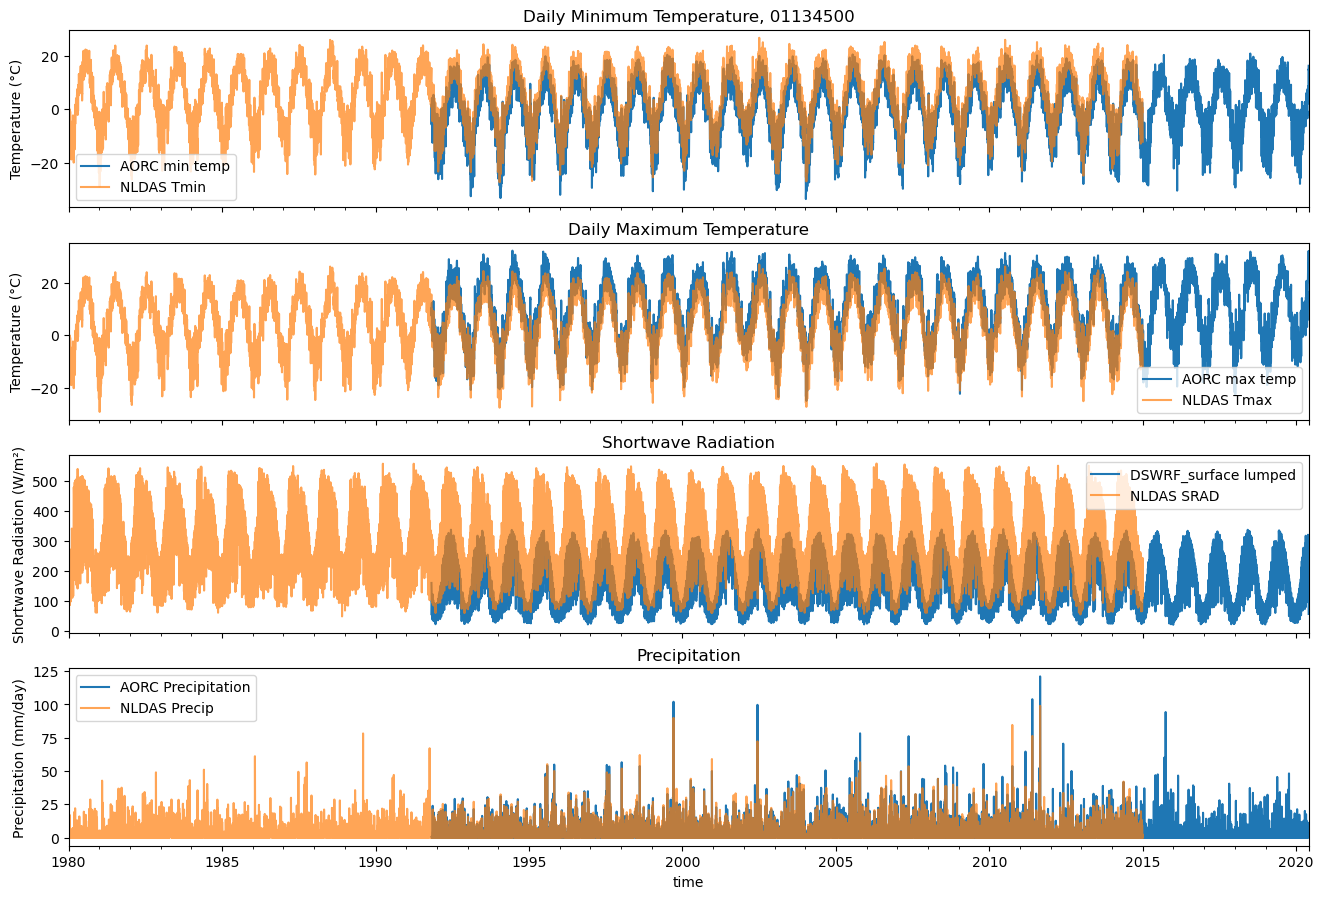

In [ ]:

# 2) Read CAMELS forcing text file
camels_file = "/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/CAMELS_US/basin_mean_forcing/nldas/01/01134500_lump_nldas_forcing_leap.txt"

camels_df = pd.read_csv(camels_file, sep=r"\s+", skiprows=3)

new_daily_dataset = xr.open_dataset(daily_path / "01134500.nc")
# build datetime index
# Option A: rename then build datetime
camels_df = camels_df.rename(columns={"Year":"year","Mnth":"month","Day":"day"})
camels_df["time"] = pd.to_datetime(camels_df[["year","month","day"]])
camels_df = camels_df.set_index("time")

# plot
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Example: daily min temp
ax = axes[0]
min_temp = new_daily_dataset["TMP_2maboveground_min"]
min_temp.plot(ax=ax, label="AORC min temp")
camels_df["Tmin(C)"].plot(ax=ax, label="NLDAS Tmin", alpha=0.7)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily Minimum Temperature, 01134500")
ax.legend()

ax = axes[1]
max_temp = new_daily_dataset["TMP_2maboveground_max"]
max_temp.plot(ax=ax, label="AORC max temp")
camels_df["Tmax(C)"].plot(ax=ax, label="NLDAS Tmax", alpha=0.7)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily Maximum Temperature")
ax.legend()

# DSWRF from your dataset
ax = axes[2]
sw_daily = new_daily_dataset["DSWRF_surface"].to_pandas()
sw_daily.plot(ax = ax, label="DSWRF_surface lumped")
camels_df["SRAD(W/m2)"].plot(ax = ax,label="NLDAS SRAD", alpha=0.7)
ax.set_ylabel("Shortwave Radiation (W/m²)")
ax.set_title("Shortwave Radiation")
ax.legend()

ax = axes[3]
precip_temp = new_daily_dataset["APCP_surface"].to_pandas()
precip_temp.plot(ax = ax, label="AORC Precipitation")
camels_df["PRCP(mm/day)"].plot(ax = ax, label="NLDAS Precip", alpha=0.7)
ax.set_ylabel("Precipitation (mm/day)")
ax.set_title("Precipitation")
ax.legend()

plt.show()

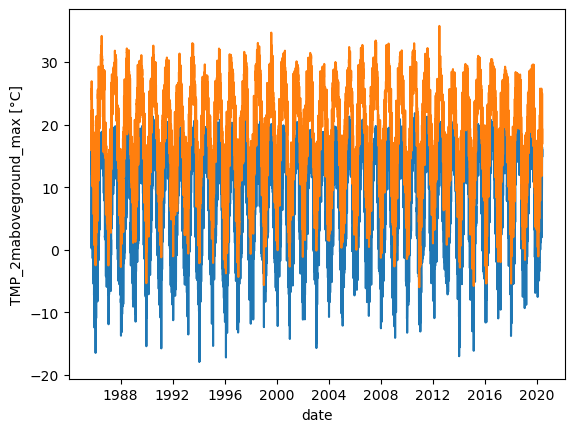

In [ ]:
new_daily_dataset['TMP_2maboveground_min'].plot(label="AORC min temp")
new_daily_dataset['TMP_2maboveground_max'].plot(label="AORC max temp")

In [2]:
import numpy as np
hourly_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series")
dataset = xr.open_dataset(hourly_path / "02177000.nc")
# Quick check: count NaNs per variable
for var in dataset.data_vars:
    n_missing = np.isnan(dataset[var]).sum().item()
    print(f"{var}: {n_missing} missing values")

APCP_surface: 242 missing values
TMP_2maboveground: 122 missing values
PRES_surface: 219 missing values
DSWRF_surface: 0 missing values
DLWRF_surface: 294 missing values
SPFH_2maboveground: 171 missing values
UGRD_10maboveground: 99 missing values
VGRD_10maboveground: 122 missing values
qobs_mm_per_hour: 12978 missing values


In [7]:
one_day = dataset.sel(date="2005-09-25")
one_day

<xarray.Dataset> Size: 2kB
Dimensions:              (date: 24)
Coordinates:
  * date                 (date) datetime64[ns] 192B 2005-09-25 ... 2005-09-25...
Data variables:
    APCP_surface         (date) float64 192B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    TMP_2maboveground    (date) float64 192B nan nan nan nan ... nan nan nan nan
    PRES_surface         (date) float64 192B 9.338e+04 9.339e+04 ... 9.319e+04
    DSWRF_surface        (date) float64 192B 0.0 0.0 0.0 ... 296.6 173.5 49.05
    DLWRF_surface        (date) float64 192B 371.3 367.9 364.5 ... 410.8 409.0
    SPFH_2maboveground   (date) float64 192B 0.01403 0.01304 ... 0.01577 0.01554
    UGRD_10maboveground  (date) float64 192B -2.425 -2.587 ... -4.907 -5.211
    VGRD_10maboveground  (date) float64 192B 2.751 2.535 2.303 ... 5.189 5.094
    qobs_mm_per_hour     (date) float64 192B nan nan nan nan ... nan nan nan nan
Attributes:
    history:      Created Fri May 16 18:47:27 2025
    epoch_start:  01/01/70 00:00:00

In [8]:
for var in dataset.data_vars:
    missing_idx = dataset[var].where(np.isnan(dataset[var]), drop=True)
    if missing_idx.size > 0:
        print(f"{var}: missing at {missing_idx['date'].values[:10]} ...")  # show first 10

APCP_surface: missing at ['1990-07-19T00:00:00.000000000' '1990-07-19T01:00:00.000000000'
 '1990-07-19T02:00:00.000000000' '1990-07-19T03:00:00.000000000'
 '1990-07-19T04:00:00.000000000' '1990-07-19T05:00:00.000000000'
 '1990-07-19T06:00:00.000000000' '1990-07-19T07:00:00.000000000'
 '1990-07-19T08:00:00.000000000' '1990-07-19T09:00:00.000000000'] ...
TMP_2maboveground: missing at ['2005-09-25T00:00:00.000000000' '2005-09-25T01:00:00.000000000'
 '2005-09-25T02:00:00.000000000' '2005-09-25T03:00:00.000000000'
 '2005-09-25T04:00:00.000000000' '2005-09-25T05:00:00.000000000'
 '2005-09-25T06:00:00.000000000' '2005-09-25T07:00:00.000000000'
 '2005-09-25T08:00:00.000000000' '2005-09-25T09:00:00.000000000'] ...
PRES_surface: missing at ['1988-02-07T00:00:00.000000000' '1988-02-07T01:00:00.000000000'
 '1988-02-07T02:00:00.000000000' '1988-02-07T03:00:00.000000000'
 '1988-02-07T04:00:00.000000000' '1988-02-07T05:00:00.000000000'
 '1988-02-07T06:00:00.000000000' '1988-02-07T07:00:00.000000000'


In [8]:
daily_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Daily/time_series")

dataset_daily = xr.open_dataset(daily_path / "02177000.nc")
# Quick check: count NaNs per variable
for var in dataset_daily.data_vars:
    n_missing = np.isnan(dataset_daily[var]).sum().item()
    print(f"{var}: {n_missing} missing values")

APCP_surface: 0 missing values
TMP_2maboveground_min: 5 missing values
TMP_2maboveground_max: 5 missing values
PRES_surface: 9 missing values
DSWRF_surface: 0 missing values
DLWRF_surface: 12 missing values
SPFH_2maboveground: 7 missing values
UGRD_10maboveground: 4 missing values
VGRD_10maboveground: 5 missing values
QObs_mm_per_day: 0 missing values


# Fill in NaNs in Daily

In [ ]:
import numpy as np
daily_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Daily/time_series")
dataset = xr.open_dataset(daily_path / "02177000.nc")


missing_idx = dataset['TMP_2maboveground_min'].where(np.isnan(dataset['TMP_2maboveground_min']), drop=True)
if missing_idx.size > 0:
    print(f"{'TMP_2maboveground_min'}: missing at {missing_idx['date'].values[:20]} ...") 

TMP_2maboveground_min: missing at ['2005-09-25T00:00:00.000000000' '2005-09-26T00:00:00.000000000'
 '2005-09-27T00:00:00.000000000' '2007-08-17T00:00:00.000000000'
 '2007-08-18T00:00:00.000000000'] ...


# Jonathan's AORC Data

Previous files Andy gave had NAs, we will try this one Jonathan has:
https://www.hydroshare.org/resource/c738c05278a34bc9848dd14d61cffab9/

## Making into netCDF files

The files come in the format of folders naemd "water_year_XXXX" from 1980 to 2024. Within each folder
"BBBBBBBB_1980_to_2024_agg_rounded_WRXXXX.csv" where BBBBBBBB is the 8-digit HUC basin ID that should match camels, and XXXX is the water year this folder is in. 

The colums are:
* time
* Total Precipitaion (APCP_surface) - Hourly total precipitation (kgm-2 or mm) for Calibration (AORC) dataset
* Air Temperature (TMP_2maboveground) - Temperature (at 2 m above-ground-level (AGL)) (K)
* Specific Humidity (SPFH_2maboveground) - Specific humidity (at 2 m AGL) (g g-1)
* Downward Long-Wave Radiation Flux (DLWRF_surface) - longwave (infrared) radiation flux (at the surface) (W m-2)
* Downward Short-Wave Radiation Flux (DSWRF_surface) - Downward shortwave (solar) radiation flux (at the surface) (W m-2)
* Pressure (PRES_surface) - Air pressure (at the surface) (Pa)
* U-Component of Wind (UGRD_10maboveground) - (west-east) - components of the wind (at 10 m AGL) (m s-1)
* V-Component of Wind (VGRD_10maboveground) - (south-north) - components of the wind (at 10 m AGL) (m s-1)

These are hourly data and should connect without skipping hours. I want to aggregate them into netCDF files that are named after basins all in one folder. 

In [15]:
from pathlib import Path
import re
import pandas as pd
import xarray as xr
import numpy as np

raw_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Raw")
hourly_destination = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series")

years = range(1980, 2024)
vars = [
    "APCP_surface",  # Precipitation
    "TMP_2maboveground",  # Temperature 
    "PRES_surface",  # Pressure
    "DSWRF_surface",  # Downward Shortwave Radiation
    "DLWRF_surface",  # Downward Longwave Radiation
    "SPFH_2maboveground",  # Specific Humidity
    "UGRD_10maboveground",  # U-component of Wind
    "VGRD_10maboveground",  # V-component of Wind
    ]
var_units = {
    "APCP_surface": "mm",
    "TMP_2maboveground": "K",
    "PRES_surface": "Pa",
    "DSWRF_surface": "W/m²",
    "DLWRF_surface": "W/m²",
    "SPFH_2maboveground": "g/g",
    "UGRD_10maboveground": "m/s",
    "VGRD_10maboveground": "m/s",
}

In [7]:
# Checking all folders have the same basin files

# --- Discover basin IDs from water_year_1980 ---
wy1980 = raw_path / "water_year_1980"
assert wy1980.is_dir(), f"Missing folder: {wy1980}"

# filenames look like: BBBBBBBB_1980_to_2024_agg_rounded_WRXXXX.csv
fname_re = re.compile(r"(?P<huc>\d{7,8})_")
basins = []
for p in sorted(wy1980.glob("*_agg_rounded_WR*.csv")):
    m = fname_re.search(p.name)
    if m:
        h = re.sub(r"\D+", "", m.group("huc"))
        if len(h) == 7:
            h = "0" + h
        basins.append(h)
basins = sorted(set(basins))
print(f"Found {len(basins)} basins in water_year_1980")

for y in years:
    folder = raw_path / f"water_year_{y}"
    assert folder.is_dir(), f"Missing folder: {folder}"
    basins_in_folder = []
    for p in sorted(folder.glob("*_agg_rounded_WR*.csv")):
        m = fname_re.search(p.name)
        if m:
            h = re.sub(r"\D+", "", m.group("huc"))
            if len(h) == 7:
                h = "0" + h
            basins_in_folder.append(h)
    basins_in_folder = sorted(set(basins_in_folder))
    if basins_in_folder != basins:
        missing = set(basins) - set(basins_in_folder)
        extra = set(basins_in_folder) - set(basins)
        print(f"Year {y}: Mismatch in basins!")
        if missing:
            print(f"  Missing basins: {sorted(missing)}")
        if extra:
            print(f"  Extra basins: {sorted(extra)}")
    else:
        print(f"Year {y}: All basins match.")

Found 667 basins in water_year_1980
Year 1980: All basins match.
Year 1981: All basins match.
Year 1982: All basins match.
Year 1983: All basins match.
Year 1984: All basins match.
Year 1985: All basins match.
Year 1986: All basins match.
Year 1987: All basins match.
Year 1988: All basins match.
Year 1989: All basins match.
Year 1990: All basins match.
Year 1991: All basins match.
Year 1992: All basins match.
Year 1993: All basins match.
Year 1994: All basins match.
Year 1995: All basins match.
Year 1996: All basins match.
Year 1997: All basins match.
Year 1998: All basins match.
Year 1999: All basins match.
Year 2000: All basins match.
Year 2001: All basins match.
Year 2002: All basins match.
Year 2003: All basins match.
Year 2004: All basins match.
Year 2005: All basins match.
Year 2006: All basins match.
Year 2007: All basins match.
Year 2008: All basins match.
Year 2009: All basins match.
Year 2010: All basins match.
Year 2011: All basins match.
Year 2012: All basins match.
Year 20

All the basins do indeed exists in every water year folder, so we'll just use the first one. 

In [52]:
# Go through each basin and compile its data across all water years folders
for b in basins:
    print(f"Processing basin {b}...")
    basin_dfs = []
    for y in years:
        folder = raw_path / f"water_year_{y}"
        file_pattern = f"{b}_1980_to_2024_agg_rounded_WR*.csv"
        files = list(folder.glob(file_pattern))
        if not files:
            print(f"  Warning: No file found for basin {b} in year {y}")
            continue
        if len(files) > 1:
            print(f"  Warning: Multiple files found for basin {b} in year {y}, using the first one.")
        file = files[0]
        df = pd.read_csv(file)
        
        # --- key fix: standardize the timestamp column to 'date' ---
        if "date" not in df.columns:
            # handle case-insensitive 'time'
            time_col = next((c for c in df.columns if str(c).strip().lower() == "time"), None)
            if time_col is None:
                raise ValueError(f"No 'time' (or 'date') column in {file}")
            df = df.rename(columns={time_col: "date"})

        # Convert 'date' column to datetime
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        basin_dfs.append(df)
    
    if not basin_dfs:
        print(f"  No data found for basin {b}, skipping.")
        continue
    
    # Concatenate all yearly DataFrames
    full_basin_df = pd.concat(basin_dfs)
    
    # Create xarray Dataset
    ds = xr.Dataset()
    for var in vars:
        if var in full_basin_df.columns:
            da = xr.DataArray(
                full_basin_df[var].values,
                coords={"date": full_basin_df.index},
                dims=["date"],
                name=var
            )
            da.attrs['units'] = var_units.get(var, "")
            ds[var] = da
        else:
            print(f"  Warning: Variable {var} not found in data for basin {b}")
    
    # convert TMP_2maboveground from Kelvin to Celsius
    if "TMP_2maboveground" in ds:
        ds["TMP_2maboveground"] = ds["TMP_2maboveground"] - 273.15
        ds["TMP_2maboveground"].attrs['units'] = "°C"
    else:
        print(f"  Warning: TMP_2maboveground not found in dataset for basin {b}")
    
    # double check time series is the same increment
    time_diffs = ds['date'].diff('date').values
    unique_diffs = np.unique(time_diffs)
    if len(unique_diffs) != 1 or unique_diffs[0] != np.timedelta64(1, 'h'):
        print(f"  Warning: Inconsistent time intervals in basin {b}: {unique_diffs}")
        
    # Save to NetCDF
    out_file = hourly_destination / f"{b}.nc"
    ds.to_netcdf(out_file)
    print(f"  Saved to {out_file}")

Processing basin 01013500...
  Saved to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series/01013500.nc
Processing basin 01022500...
  Saved to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series/01022500.nc
Processing basin 01030500...
  Saved to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series/01030500.nc
Processing basin 01031500...
  Saved to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series/01031500.nc
Processing basin 01047000...
  Saved to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/Jonathan_AORC_Hourly/time_series/01047000.nc
Proce

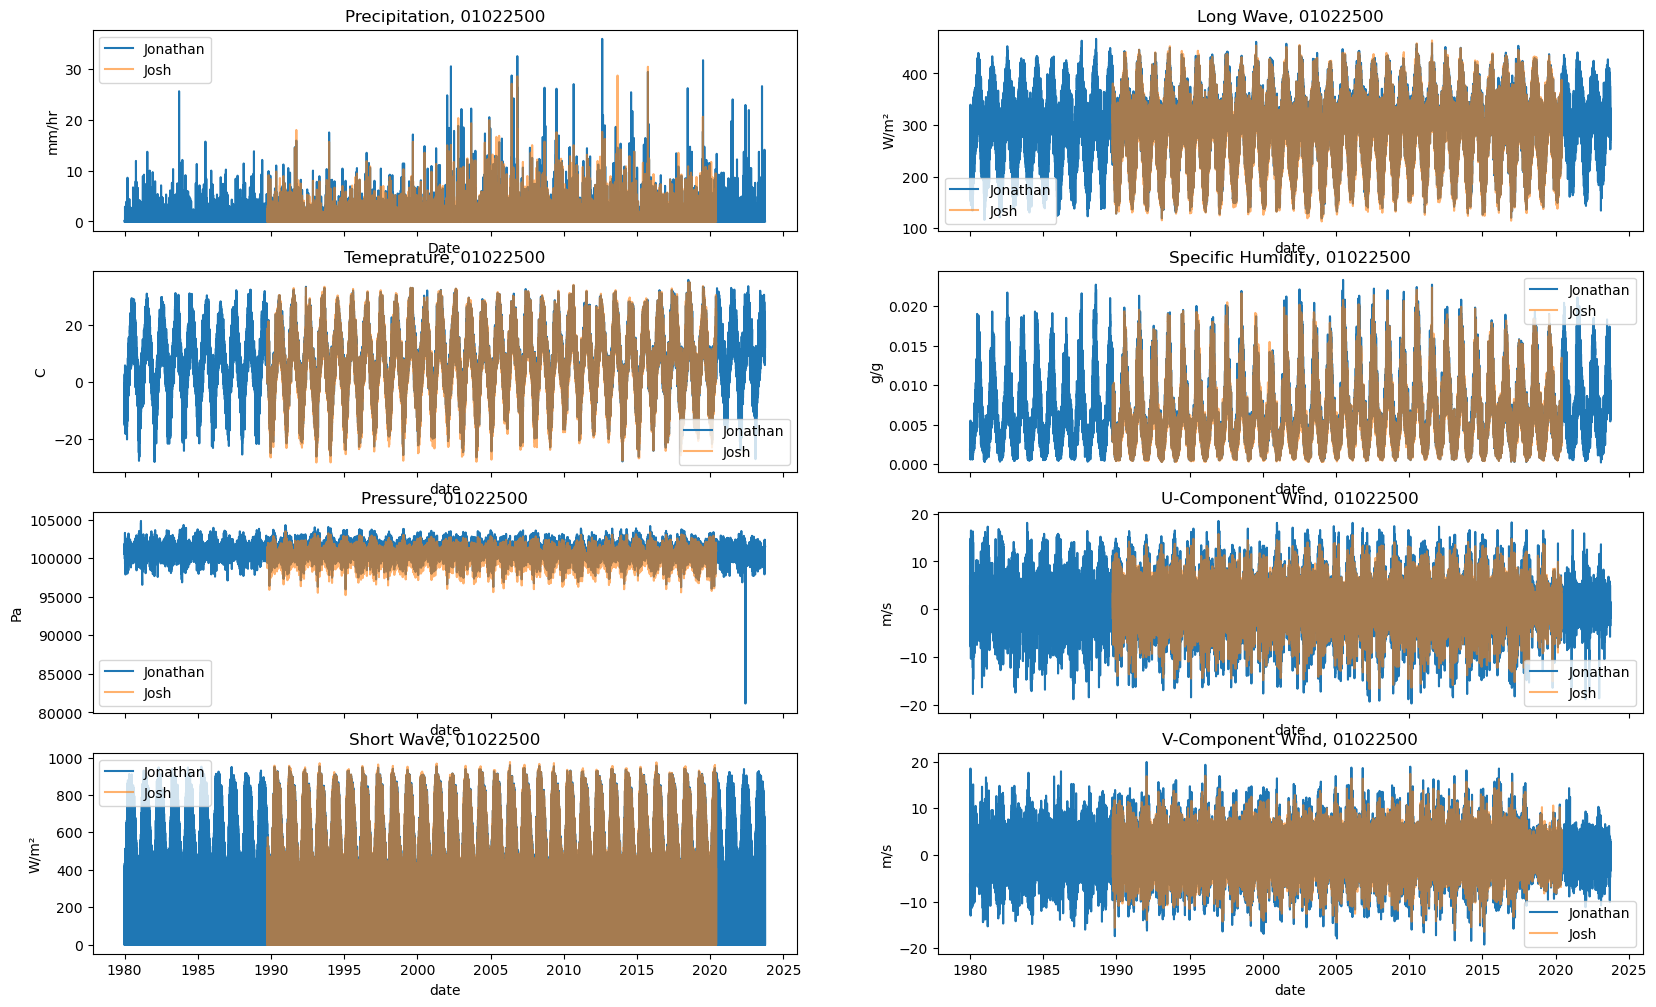

In [54]:
jonathan_data = xr.open_dataset(hourly_destination / "01022500.nc")
josh_data = xr.open_dataset("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series/01022500.nc")


import matplotlib.pyplot as plt
# plot
fig, axes = plt.subplots(4, 2, figsize=(20, 12), sharex=True)

# Precip
ax = axes[0, 0]
jonathan_data["APCP_surface"].plot(ax=ax, label="Jonathan")
josh_data["APCP_surface"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("mm/hr")
ax.set_xlabel("Date")
ax.set_title("Precipitation, 01022500")
ax.legend()

# Temp
ax = axes[1, 0]
jonathan_data["TMP_2maboveground"].plot(ax=ax, label="Jonathan")
josh_data["TMP_2maboveground"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("C")
ax.set_title("Temeprature, 01022500")
ax.legend()

# Pressure
ax = axes[2, 0]
jonathan_data["PRES_surface"].plot(ax=ax, label="Jonathan")
josh_data["PRES_surface"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("Pa")
ax.set_title("Pressure, 01022500")
ax.legend()

# DSWRF
ax = axes[3, 0]
jonathan_data["DSWRF_surface"].plot(ax=ax, label="Jonathan")
josh_data["DSWRF_surface"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("W/m²")
ax.set_title("Short Wave, 01022500")
ax.legend()

# DLWRF
ax = axes[0, 1]
jonathan_data["DLWRF_surface"].plot(ax=ax, label="Jonathan")
josh_data["DLWRF_surface"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("W/m²")
ax.set_title("Long Wave, 01022500")
ax.legend()

# Specific Humidity
ax = axes[1, 1]
jonathan_data["SPFH_2maboveground"].plot(ax=ax, label="Jonathan")
josh_data["SPFH_2maboveground"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("g/g")
ax.set_title("Specific Humidity, 01022500")
ax.legend()

# Specific Humidity
ax = axes[2, 1]
jonathan_data["UGRD_10maboveground"].plot(ax=ax, label="Jonathan")
josh_data["UGRD_10maboveground"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("m/s")
ax.set_title("U-Component Wind, 01022500")
ax.legend()

# Specific Humidity
ax = axes[3, 1]
jonathan_data["VGRD_10maboveground"].plot(ax=ax, label="Jonathan")
josh_data["VGRD_10maboveground"].plot(ax=ax, label="Josh", alpha=0.6)
ax.set_ylabel("m/s")
ax.set_title("V-Component Wind, 01022500")
ax.legend()

plt.show()

In [43]:
for var in jonathan_data.data_vars:
    n_missing = np.isnan(jonathan_data[var]).sum().item()
    print(f"{var}: {n_missing} missing values")

APCP_surface: 48 missing values
TMP_2maboveground: 240 missing values
PRES_surface: 0 missing values
DSWRF_surface: 48 missing values
DLWRF_surface: 72 missing values
SPFH_2maboveground: 0 missing values
UGRD_10maboveground: 24 missing values
VGRD_10maboveground: 48 missing values


In [44]:
for var in josh_data.data_vars:
    n_missing = np.isnan(josh_data[var]).sum().item()
    print(f"{var}: {n_missing} missing values")

APCP_surface: 49 missing values
TMP_2maboveground: 340 missing values
PRES_surface: 49 missing values
DSWRF_surface: 49 missing values
DLWRF_surface: 73 missing values
SPFH_2maboveground: 0 missing values
UGRD_10maboveground: 25 missing values
VGRD_10maboveground: 50 missing values
qobs_mm_per_hour: 62181 missing values


In [45]:
missing_idx = jonathan_data['TMP_2maboveground'].where(np.isnan(jonathan_data['TMP_2maboveground']), drop=True)
if missing_idx.size > 0:
    print(f"{'TMP_2maboveground'}: missing at {missing_idx['date'].values[:20]} ...") 

TMP_2maboveground: missing at ['1989-07-24T00:00:00.000000000' '1989-07-24T01:00:00.000000000'
 '1989-07-24T02:00:00.000000000' '1989-07-24T03:00:00.000000000'
 '1989-07-24T04:00:00.000000000' '1989-07-24T05:00:00.000000000'
 '1989-07-24T06:00:00.000000000' '1989-07-24T07:00:00.000000000'
 '1989-07-24T08:00:00.000000000' '1989-07-24T09:00:00.000000000'
 '1989-07-24T10:00:00.000000000' '1989-07-24T11:00:00.000000000'
 '1989-07-24T12:00:00.000000000' '1989-07-24T13:00:00.000000000'
 '1989-07-24T14:00:00.000000000' '1989-07-24T15:00:00.000000000'
 '1989-07-24T16:00:00.000000000' '1989-07-24T17:00:00.000000000'
 '1989-07-24T18:00:00.000000000' '1989-07-24T19:00:00.000000000'] ...


In [51]:
var = "TMP_2maboveground"
mask = np.isnan(jonathan_data[var])

# use 'date' if present, otherwise 'time'
coord = "date" if "date" in jonathan_data.coords else "time"

# timestamps where var is missing
bad_times = jonathan_data[coord].where(mask, drop=True).values

# convert to day precision and unique
bad_dates = np.unique(pd.to_datetime(bad_times).values.astype("datetime64[D]"))


print(f"{var} from Jonathan's 01022500: {bad_dates} ... (unique missing days: {bad_dates.size})")

TMP_2maboveground from Jonathan's 01022500: ['1989-07-24' '1992-02-25' '1992-02-26' '1992-02-27' '1992-02-28'
 '1992-02-29' '1996-10-21' '1996-10-22' '1996-10-23' '1996-10-24'] ... (unique missing days: 10)


In [50]:
var = "TMP_2maboveground"
mask = np.isnan(josh_data[var])

# use 'date' if present, otherwise 'time'
coord = "date" if "date" in josh_data.coords else "time"

# timestamps where var is missing
bad_times = josh_data[coord].where(mask, drop=True).values

# convert to day precision and unique
bad_dates = np.unique(pd.to_datetime(bad_times).values.astype("datetime64[D]"))


print(f"{var} from Josh's 01022500: {bad_dates} ... (unique missing days: {bad_dates.size})")

TMP_2maboveground from Josh's 01022500: ['1992-02-25' '1992-02-26' '1992-02-27' '1992-02-28' '1992-02-29'
 '1992-03-01' '1996-10-21' '1996-10-22' '1996-10-23' '1996-10-24'
 '1996-10-25' '2000-08-07' '2000-08-08' '2000-08-09' '2000-08-10'
 '2016-07-11' '2016-07-12' '2016-07-13'] ... (unique missing days: 18)
